In [1]:
import pandas as pd
import numpy as np

import joblib

import matplotlib.pyplot as plt
import seaborn as sns

import shap

In [2]:
best_model = joblib.load(
    "../models/tuned_random_forest_model.pkl"
)

In [3]:
df = pd.read_csv(
    "../../data/processed/feature_engineered_dataset.csv"
)

X = df.drop("Yield", axis=1)

y = df["Yield"]

In [4]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
5,Production,0.481808
16,Production_per_area,0.180861
0,Crop,0.112185
4,Area,0.038632
7,Fertilizer,0.031031
8,Pesticide,0.027661
2,Season,0.024884
13,P,0.020262
12,N,0.018964
3,State,0.013748


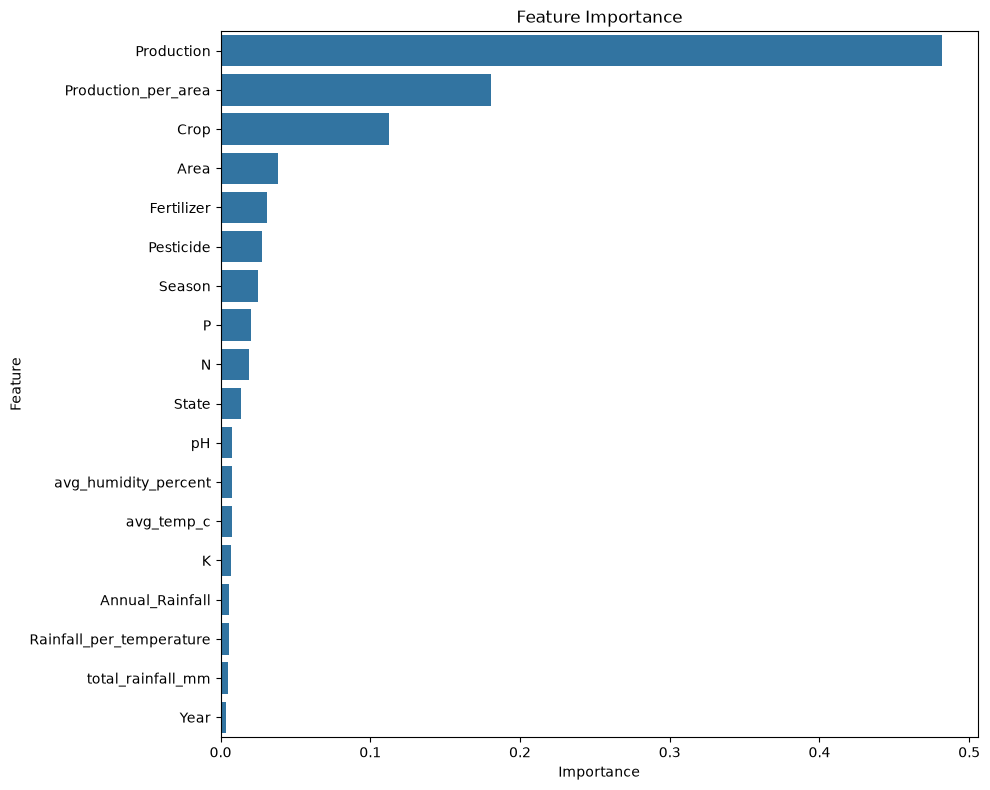

In [5]:

plt.figure(figsize=(10,8))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

# Prevent labels from getting cut off
plt.tight_layout()

# Save the figure
plt.savefig(
    "../../reports/figures/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the figure
plt.show()

In [ ]:
explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X)

In [ ]:
shap.summary_plot(
    shap_values,
    X
)

In [ ]:
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar"
)

In [ ]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X.iloc[0]
)